<a href="https://colab.research.google.com/github/mzsmarcos/Analytics/blob/main/MachineLearningPredicao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise em um dataset de campanha de marketing**
Uma empresa está investindo mensalmente em plataformas de publicidade online,
como Youtube, Facebook e newspaper, para a prospecção de leads (pessoas
interessadas em seus produtos). A fim de acompanhar o desempenho desses
investimentos, a empresa registra todos os gastos com publicidade e todos os
retornos de vendas gerados a partir desses investimentos.
Para entender melhor a relação entre as variáveis presentes nesses registros e
identificar os fatores que mais impactam na geração de leads, a empresa
solicitou a análise de um especialista em dados. Além disso, a empresa busca
criar um modelo de predição de valores utilizando Machine Learning para estimar o retorno de vendas que
pode ser gerado a partir de um determinado investimento em publicidade.



In [ ]:
# Importação das Bibliotecas

import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
from io import StringIO



In [ ]:
# Acessando a base de dados

base_mkt = pd.read_csv('/content/MKT.csv', sep = ',')
base_mkt.head()


,youtube,facebook,newspaper,sales
0,84.72,19.20,48.96,12.60
1,351.48,33.96,51.84,25.68
2,135.48,20.88,46.32,14.28
3,116.64,1.80,36.00,11.52
4,318.72,24.00,0.36,20.88


In [ ]:
base_mkt.tail()

,youtube,facebook,newspaper,sales
166,45.84,4.44,16.56,9.12
167,113.04,5.88,9.72,11.64
168,212.40,11.16,7.68,15.36
169,340.32,50.40,79.44,30.60
170,278.52,10.32,10.44,16.08


**Explorando** as informações das variáveis presentes no dataset para identificar possíveis inconsistências, como valores ausentes, dados duplicados ou outliers.
Não foram encontrados dados faltantes.


In [ ]:
base_mkt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   youtube    171 non-null    float64
 1   facebook   171 non-null    float64
 2   newspaper  171 non-null    float64
 3   sales      171 non-null    float64
dtypes: float64(4)
memory usage: 5.5 KB


Análise descritiva das variáveis:
Registros: 171
1. youtube
 Os gastos médios em anúncios no YouTube é de 178.02. A dispersão em relação à média é de 102.45, indicando que os valores variam consideravelmente. O menor gasto registrado é 0.84. 25% dos valores são menores ou iguais a 91.08. A mediana é 179.76, indicando que metade dos valores é menor ou igual a esse valor. 75% dos valores são menores ou iguais a 262.98. O maior gasto registrado é 355.68.
2. facebook
Os gastos médios em anúncios no Facebook são 27.67. O desvio padrão é 17.91, sugerindo variação moderada. O menor gasto registrado é 0. 25% dos valores são menores ou iguais a 11.70. A mediana é 26.76, mostrando que metade dos valores é menor ou igual a isso. 75% dos valores são menores ou iguais a 43.68. O maior gasto registrado é 59.52 unidades.
3. newspaper
O gasto médio em anúncios em jornais é de 35.24. O desvio padrão é 24.90 unidades, indicando uma variação significativa. O menor gasto registrado é 0.36. 25% dos valores são menores ou iguais a 13.74. A mediana é 31.08. 75% dos valores são menores ou iguais a 50.88. O maior gasto registrado é 121.08.
4. sales
A média das vendas é de 16.92.O desvio padrão é 6.31 unidades, indicando uma variação moderada. A menor venda registrada é 1.92. 25% das vendas são menores ou iguais a 12.54. A mediana das vendas é 15.48. 75% das vendas são menores ou iguais a 20.82. A maior venda registrada é 32.40.
Observações Gerais
Dispersão: O gasto com anúncios no YouTube tem a maior variação entre as mídias, enquanto o Facebook apresenta a menor variação.
Gastos: Em média, os gastos em anúncios no YouTube são os mais altos, seguidos por jornal e Facebook.
Vendas: As vendas apresentam uma mediana próxima à média (15.48 e 16.92, respectivamente), indicando uma distribuição relativamente simétrica.


In [ ]:
# Análise descritiva das variáveis

base_mkt.describe()

,youtube,facebook,newspaper,sales
count,171.000000,171.000000,171.000000,171.000000
mean,178.021053,27.671579,35.240000,16.922807
std,102.449597,17.913532,24.902918,6.314608
min,0.840000,0.000000,0.360000,1.920000
25%,91.080000,11.700000,13.740000,12.540000
50%,179.760000,26.760000,31.080000,15.480000
75%,262.980000,43.680000,50.880000,20.820000
max,355.680000,59.520000,121.080000,32.400000


In [ ]:
print(base_mkt.columns)

Index(['youtube', 'facebook', 'newspaper', 'sales'], dtype='object')


In [ ]:
# Resetando o índice das colunas
base_mkt.reset_index(inplace=True)

In [ ]:
# Renomeando as colunas
base_mkt.rename(columns={'index': 'id_inv'}, inplace=True)

In [ ]:
base_mkt.head()

,id_inv,youtube,facebook,newspaper,sales
0,0,84.72,19.20,48.96,12.60
1,1,351.48,33.96,51.84,25.68
2,2,135.48,20.88,46.32,14.28
3,3,116.64,1.80,36.00,11.52
4,4,318.72,24.00,0.36,20.88


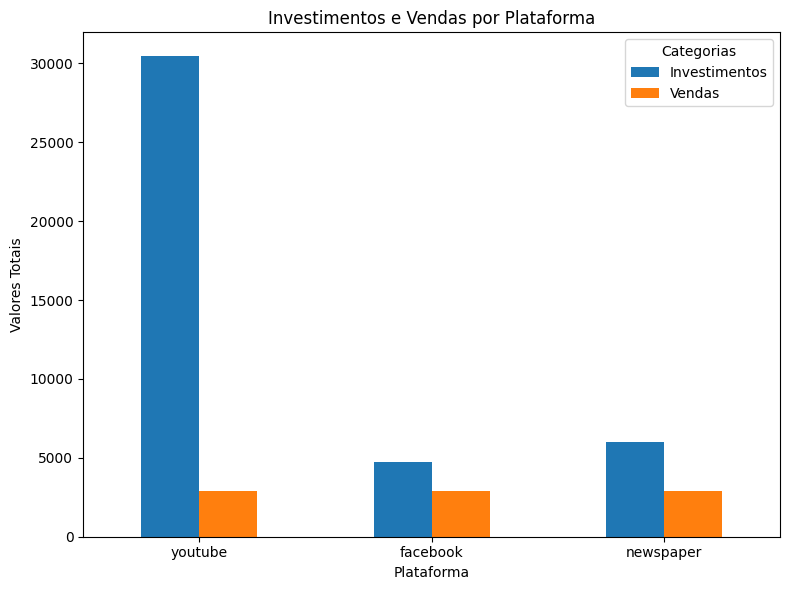

In [ ]:
# Somando os valores investidos em cada coluna (exceto a coluna 'sales')
investment_sums = base_mkt[['youtube', 'facebook', 'newspaper']].sum()

sales_total = base_mkt['sales'].sum()

data = pd.DataFrame({
    'Investimentos': investment_sums,
    'Vendas': [sales_total] * len(investment_sums.index)  # Repete o total de vendas para cada plataforma
}, index=investment_sums.index)


# Criando um gráfico de barras para mostrar os investimentos totais em cada plataforma
data.plot(kind='bar', figsize=(8, 6))
plt.title('Investimentos e Vendas por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Valores Totais')
plt.xticks(rotation=0)
plt.legend(title="Categorias")
plt.tight_layout()
plt.show()



In [ ]:
# Gráficos da soma dos investimentos com Plotly

import plotly.express as px

# Calculando a soma dos investimentos por plataforma
investment_sum = base_mkt[['youtube', 'facebook', 'newspaper']].sum().reset_index()
investment_sum.columns = ['Plataforma', 'Valor']

# Adicionando o total de vendas ao DataFrame
sales_total = base_mkt['sales'].sum()
investment_sum = pd.concat([
    investment_sum,
    pd.DataFrame({'Plataforma': ['Vendas'], 'Valor': [sales_total]})
], ignore_index=True)

# Criando uma coluna para categorizar os dados
investment_sum['Tipo'] = ['Investimento'] * (len(investment_sum) - 1) + ['Vendas']

# Criando o gráfico de barras interativo com separação por "Tipo"
fig = px.bar(
    investment_sum,
    x='Plataforma',
    y='Valor',
    color='Tipo',
    barmode='group',  # Agrupamento das barras lado a lado
    title='Investimentos e Vendas por Plataforma'
)

fig.show()


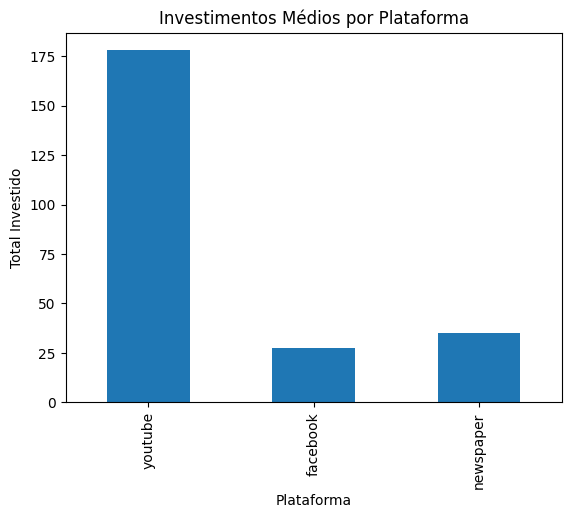

In [ ]:
# Médias os valores investidos em cada coluna (exceto a coluna 'sales')
investment_mean = base_mkt[['youtube', 'facebook', 'newspaper']].mean()

# Criando um gráfico de barras para mostrar os investimentos totais em cada plataforma
investment_mean.plot(kind='bar')
plt.title('Investimentos Médios por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Total Investido')
plt.show()

In [ ]:
# Gráficos da média dos investimentos com Plotly

investment_mean = base_mkt[['youtube', 'facebook', 'newspaper']].mean().reset_index()
investment_mean.columns = ['Plataforma', 'Média Investida']

# Criando o gráfico de barras interativo
fig = px.bar(investment_mean, x='Plataforma', y='Média Investida', title='Médias dos Investimentos por Plataforma')
fig.show()

<Axes: xlabel='sales', ylabel='Count'>

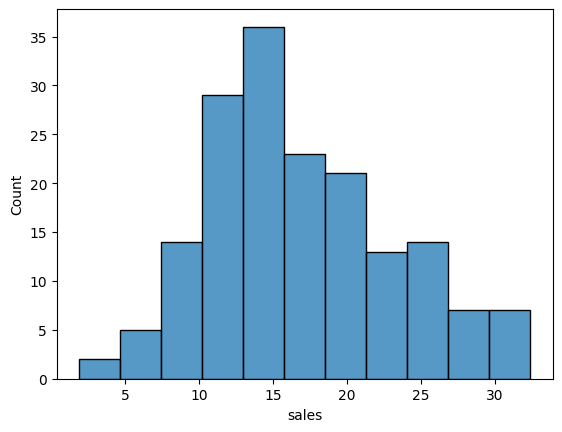

In [ ]:
sns.histplot(base_mkt["sales"])

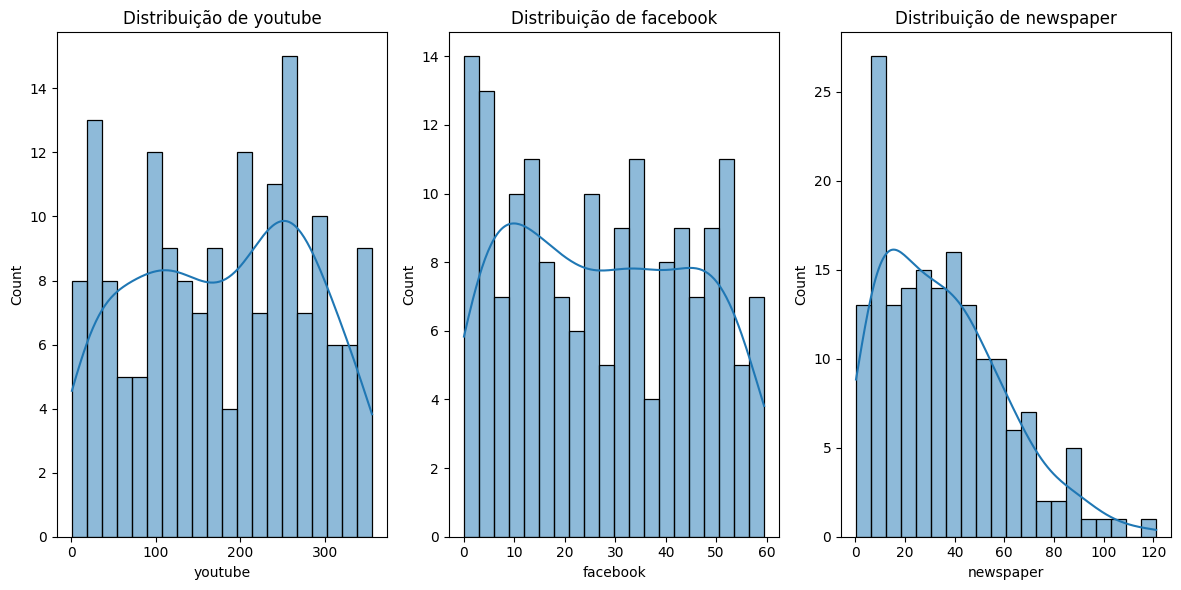

In [ ]:
# Histogramas dos investimentos por plataforma
plt.figure(figsize=(12, 6))
for i, coluna in enumerate(['youtube', 'facebook', 'newspaper']):
    plt.subplot(1, 3, i + 1)
    sns.histplot(base_mkt[coluna], kde=True, bins=20)
    plt.title(f"Distribuição de {coluna}")
plt.tight_layout()
plt.show()

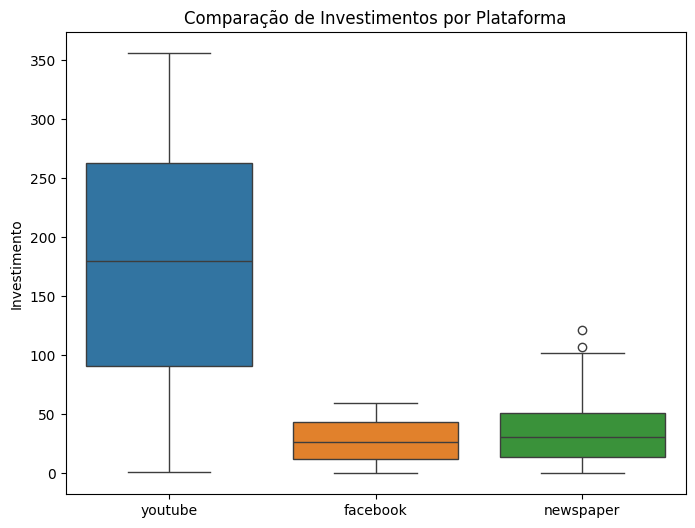

In [ ]:
# Boxplots para comparar distribuições

plt.figure(figsize=(8, 6))
sns.boxplot(data=base_mkt[['youtube', 'facebook', 'newspaper']])
plt.title("Comparação de Investimentos por Plataforma")
plt.ylabel("Investimento")
plt.show()

Visuallizações com **Plotly**

In [ ]:
pip install plotly

In [ ]:
import plotly.express as px

# Criando um histograma interativo para as plataformas
fig = px.histogram(base_mkt, x='youtube', nbins=20, title='Distribuição de Investimentos no YouTube')
fig.update_layout(
    xaxis_title='Investimento no YouTube',
    yaxis_title='Número de Ocorrências'
)
fig.show()

In [ ]:
fig = px.histogram(base_mkt, x='facebook', nbins=20, title='Distribuição de Investimentos no Facebook')
fig.update_layout(
    xaxis_title='Investimento no Facebook',
    yaxis_title='Número de Ocorrências'
)
fig.show()

In [ ]:
fig = px.histogram(base_mkt, x='newspaper', nbins=20, title='Distribuição de Investimentos no Newspaper')
fig.update_layout(
    xaxis_title='Investimento no Newspaper',
    yaxis_title='Número de Ocorrências'
)
fig.show()

O gráfico de dispersão mostra uma correlação forte entre os investimentos no Youtube e as vendas.
Coeficiente de correlação de Pearson: 0.78

In [ ]:
# Grátifo de dispersão
fig = px.scatter(base_mkt, x='youtube', y='sales', title='Investimento no YouTube vs Vendas')
fig.update_layout(
    xaxis_title='Investimento no YouTube',
    yaxis_title='Vendas'
)
fig.show()

In [ ]:
# Calculo da correção de Pearson Youtube

correlacao = base_mkt['youtube'].corr(base_mkt['sales'])
print(f"Coeficiente de correlação de Pearson: {correlacao:.2f}")

Coeficiente de correlação de Pearson: 0.78


O gráfico de dispersão mostra uma correlação moderada para forte entre os investimentos no Facebook e as vendas. Coeficiente de correlação de Pearson: 0.60

In [ ]:
fig = px.scatter(base_mkt, x='facebook', y='sales', title='Investimento no Facebook vs Vendas')
fig.update_layout(
    xaxis_title='Investimento no Facebook',
    yaxis_title='Vendas'
)
fig.show()

In [ ]:
# Calculo da correção de Pearson Facebook

correlacao = base_mkt['facebook'].corr(base_mkt['sales'])
print(f"Coeficiente de correlação de Pearson: {correlacao:.2f}")

Coeficiente de correlação de Pearson: 0.60


O gráfico de dispersão mostra uma correlação fraca entre os investimentos no Newspaper e as vendas. Coeficiente de correlação de Pearson: 0.25

In [ ]:
fig = px.scatter(base_mkt, x='newspaper', y='sales', title='Investimento no Newspaper vs Vendas')
fig.update_layout(
    xaxis_title='Investimento no Newspaper',
    yaxis_title='Vendas'
)
fig.show()

In [ ]:
# Calculo da correção de Pearson Newspaper

correlacao = base_mkt['newspaper'].corr(base_mkt['sales'])
print(f"Coeficiente de correlação de Pearson: {correlacao:.2f}")

Coeficiente de correlação de Pearson: 0.25


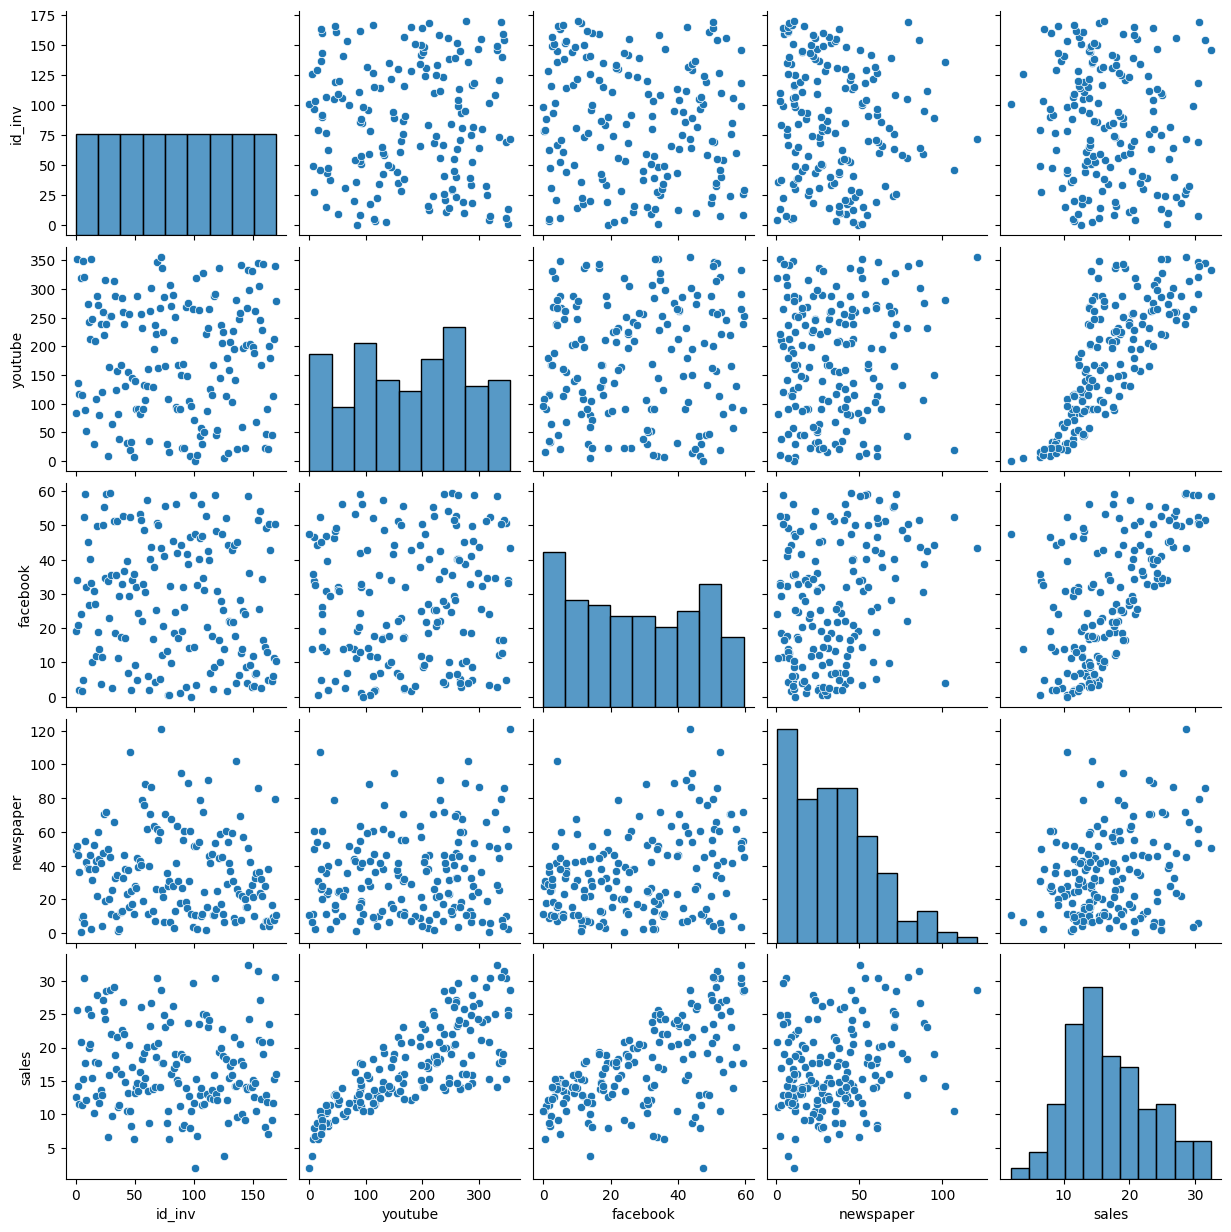

In [ ]:
# Correlação entre as variáveis

sns.pairplot(base_mkt)

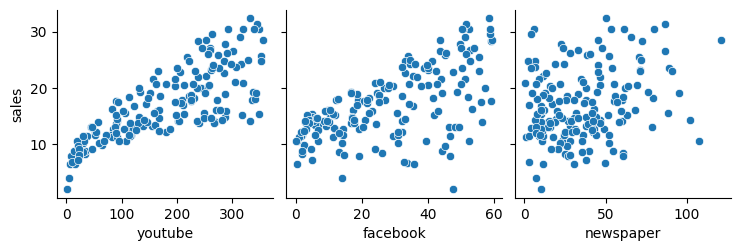

In [ ]:
# Correlação entre das variáves youtube, facebook e newspaper com o preço

sns.pairplot(base_mkt, x_vars=['youtube', 'facebook', 'newspaper'], y_vars='sales')

# **Outliers**

In [ ]:
# Calculando o Z-score
z_scores = np.abs((base_mkt - base_mkt.mean()) / base_mkt.std())

# Definindo um limiar para identificar outliers (por exemplo, Z-score > 3)
outliers = z_scores > 3

# Exibindo os outliers
outliers_df = base_mkt[outliers.any(axis=1)]
print(outliers_df)

    id_inv  youtube  facebook  newspaper  sales
72      72   355.68     43.56     121.08  28.56


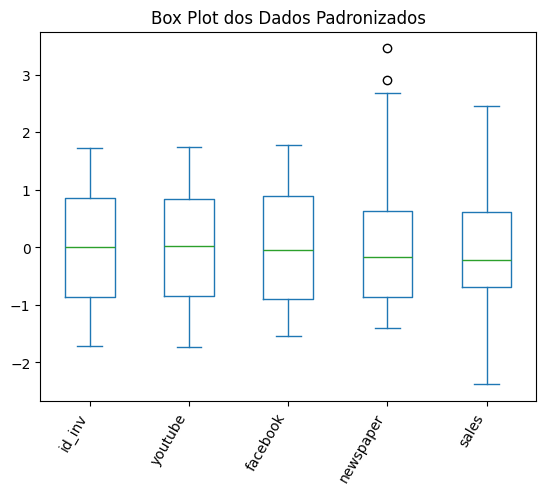

In [ ]:
# Box plot com dados padronizados

from sklearn.preprocessing import scale

base_mkt.apply(scale).plot.box()
plt.xticks(rotation=60, ha='right')
plt.title('Box Plot dos Dados Padronizados')
plt.show()

***Montagem ***do modelo de regressão para construir um modelo que seja capaz de estimar o retorno de vendas a partir de um determinado investimento.

In [ ]:
# importar a biblioteca de machine learning

from sklearn.model_selection import train_test_split

In [ ]:
# Separando as variáveis explicativas (x) da variável Y (variável target-resposta)

x = base_mkt[['youtube',	'facebook',	'newspaper'	]]

y = base_mkt[['sales']]

In [ ]:
# Criar as bases de treino e as bases de testes

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state = 42)

**Treinando o Modelo**

In [ ]:
# Imprimindo as bases criadas

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(119, 3)
(52, 3)
(119, 1)
(52, 1)


In [ ]:
# Importar o sklearn para treinar o modelo

from sklearn.linear_model import LinearRegression

In [ ]:
# Cria-se a variável para represetar a regressão

lm = LinearRegression()

In [ ]:
# Treino do modelo

lm.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Predição utilizando o modelo que foi treinado

y_pred = lm.predict(x_test)

In [ ]:
# Importa a biblioteca com métricas para análise

from sklearn.metrics import r2_score

# linha de código que compara os dados reais do dataset com a predição; quanto maior o número, mais assertivo o modelo

r = r2_score(y_test, y_pred)

O r-quadrado (coeficiente de determinação) de 0.8824 significa que 88,24% da variação nas vendas pode ser explicada pelo modelo preditivo treinado, com base nos dados disponíveis.
Alto poder explicativo: r-quadrado 88,24% indica que o modelo é bastante eficaz em capturar a relação entre as variáveis explicativas e a variável resposta (neste caso, vendas).
Apenas 11,76% da variação nas vendas não é explicada pelo modelo e pode estar associada a fatores não considerados (como sazonalidade, outros canais de marketing, ou variação aleatória).
Qualidade do modelo:

Em problemas de previsão e análise de marketing, um
r-quadrado próximo a 0.88 geralmente é considerado muito bom, sugerindo que o modelo é confiável para prever vendas com base nos dados de entrada.

In [ ]:
# imprimindo o resultado

print("r-quadrado:", r)

r-quadrado: 0.882423505618885


In [ ]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

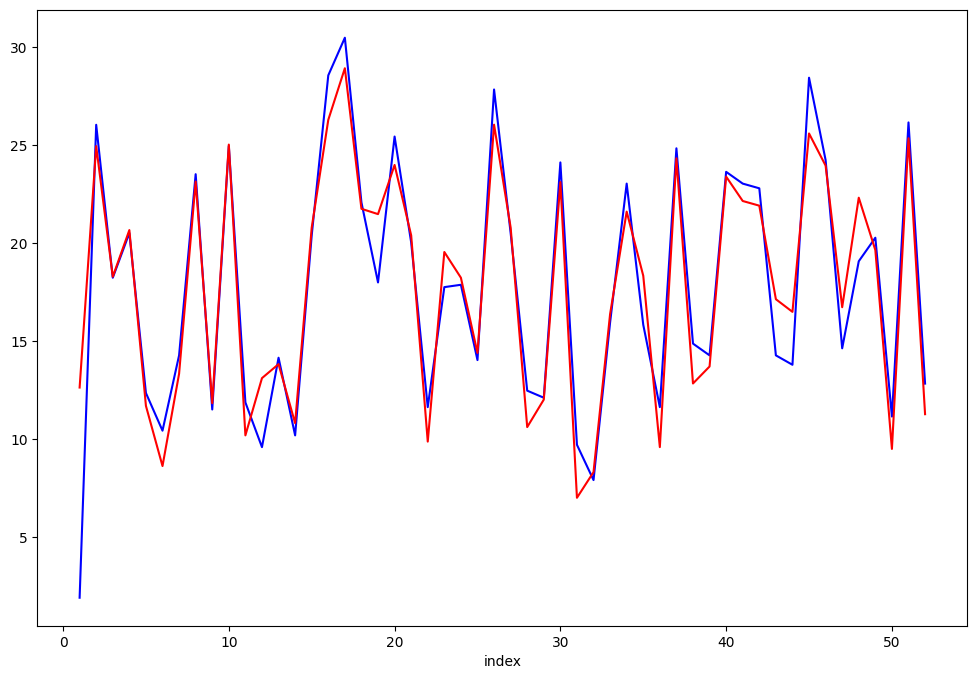

In [ ]:
c = [i for i in range(1, 53, 1)]
fig = plt.figure(figsize=(12,8))
plt.plot(c, y_test, color="blue")
plt.plot(c, y_pred, color="red")
plt.xlabel("index")
plt.ylabel

In [ ]:
# Total de Vendas
sales_total = base_mkt['sales'].sum()
sales_total

2893.7999999999993

**Aplicando** um aumento de 20% aos totais investidos em cada plataforma utilizando o modelo treinado, a venda seria de 3345.60

In [ ]:
# Prevendo as vendas com um aumento de 20% nos totais investidos em cada plataforma
# Copiando os dados originais de entrada (x)
x_new = x.copy()

# Aplicando o aumento de 20% nos investimentos
x_new[['youtube', 'facebook', 'newspaper']] *= 1.2

# Usando o modelo treinado para prever as vendas com os novos investimentos
y_new_pred = lm.predict(x_new)

# Adicionando as previsões ao DataFrame para análise
results = x_new.copy()
results['Predicted_Sales'] = y_new_pred

# Exibindo as previsões
print(results.head())


   youtube  facebook  newspaper  Predicted_Sales
0  101.664    23.040     58.752        12.588093
1  421.776    40.752     62.208        30.393637
2  162.576    25.056     55.584        15.722018
3  139.968     2.160     43.200        10.395508
4  382.464    28.800      0.432        26.376652


In [ ]:
# Calculando a nova soma de vendas previstas
new_sales_sum = np.sum(y_new_pred)

# Exibindo o resultado
print(f"Soma das vendas previstas com aumento de 20% nos investimentos seria de: {new_sales_sum:.2f}")


Soma das vendas previstas com aumento de 20% nos investimentos seria de: 3345.60
